In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [ ]:
df = pd.read_csv("../mizban_orders.csv")

In [19]:
X = df.drop(columns=["date", "orders", "completed_orders", "canceled_orders"])
y= df["orders"]

y.head(10)

0     95
1    110
2    150
3    165
4     90
5    100
6    105
7    115
8    130
9    170
Name: orders, dtype: int64

In [ ]:
def loss_function(X,y, m,b):
    
    X= np.array(X)
    y= np.array(y)

    prediction= np.dot(X , m) + b
    # mas = np.mean((y - prediction ) ** 2)
    total_mass= 0
    for i in range(len(y)):
      error = ((y - prediction) ** 2)  
      total_mass += error[i] 
    return total_mass / len(y)  
     

num_features = X.shape[1]
initial_m = np.zeros(num_features)
initial_b = 0
print(loss_function(X, y, initial_m, initial_b))
       

In [ ]:
def gradient_deccent(X,y, m_now ,b_now, alpha):
    
    m_gradient= 0
    b_gradient = 0
    
    for i in range(len(X)):
        f_wb= m_now * X[i] + b_now
        m_gradient += (1/len(X)) * (f_wb - y[i]) * X[i]
        b_gradient += (1/len(X)) * (f_wb - y[i]) 
        
    m =  m_now - (m_gradient * alpha) 
    b =  b_now - (b_gradient * alpha) 
    
    return m , b

print(gradient_deccent(X,y, 0.1, 0.2 , 0.001))

In [8]:
import numpy as np

X_mean = X.mean()
X_std = X.std()
X_scaled = np.array((X - X_mean) / X_std)

def gradient_descent(x, y, w_now, b_now, alpha=0.001):
    x_mat = np.array(x)
    y_vect = np.array(y)
    
    num_features = x_mat.shape[1]
    num_sample = len(y)
    
    w_gradient = np.zeros(num_features)
    b_gradient = 0.0
    
    for i in range(num_sample):
        f_wb = 0.0
        for j in range(num_features):
            f_wb += w_now[j] * x_mat[i][j]
        f_wb += b_now
        
        error = f_wb - y_vect[i]
        for j in range(num_features):
            w_gradient[j] += (1 / num_sample) * error * x_mat[i][j]
        
        b_gradient += (1 / num_sample) * error
        
    w = w_now - (alpha * w_gradient)              
    b = b_now - (alpha * b_gradient)
    
    return w, b              

num_feature = X_scaled.shape[1]
w = np.zeros(num_feature)
b = 0.0
alpha = 0.00001  

for i in range(1000):
    w, b = gradient_descent(X_scaled, y, w, b, alpha)
    
    if i % 200 == 0:
        print(f"Epoch {i}: w={np.round(w, 4)}, b={b:.4f}")
    
print(f"Final Result:\nWeights (w): {np.round(w, 4)}\nBias (b): {b:.4f}")


Epoch 0: w=[0.0003 0.0003 0.0004 0.0003 0.0003], b=0.0015
Epoch 200: w=[0.0675 0.069  0.0809 0.0686 0.069 ], b=0.2959
Epoch 400: w=[0.1342 0.1372 0.1607 0.1365 0.1372], b=0.5898
Epoch 600: w=[0.2003 0.2047 0.2399 0.2038 0.2047], b=0.8831
Epoch 800: w=[0.2658 0.2717 0.3186 0.2707 0.2717], b=1.1757
Final Result:
Weights (w): [0.3305 0.3378 0.3962 0.3368 0.3378]
Bias (b): 1.4664


--- Prediction Results ---
New Sample Data Input:
 weekday  is_weekend  active_users  restaurants  promotion
       6           1           600           25          1
Predicted Total Orders: 159.04



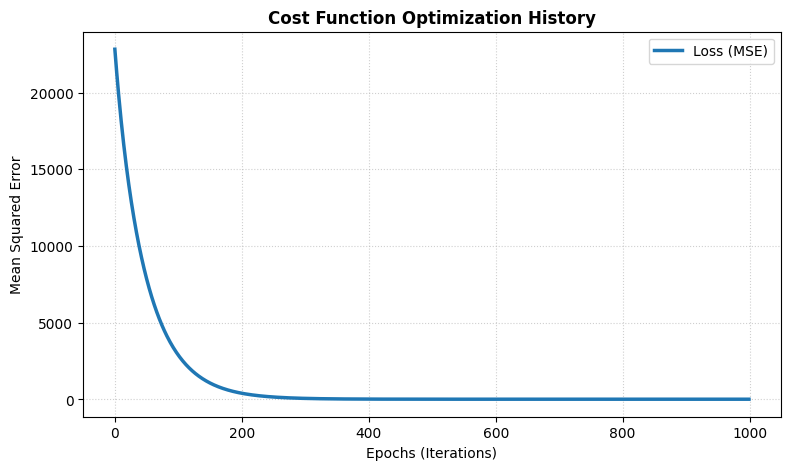

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_raw = df.drop(columns=["date", "orders", "completed_orders", "canceled_orders"])
y = df["orders"].values

X_mean = X_raw.mean()
X_std = X_raw.std()
X_scaled = np.array((X_raw - X_mean) / X_std)

def compute_loss(X, y, w, b):
    predictions = np.dot(X, w) + b
    mse = np.mean((predictions - y) ** 2)
    return mse

def gradient_descent_step(X, y, w_now, b_now, alpha):
    num_samples = len(y)
    f_wb = np.dot(X, w_now) + b_now
    error = f_wb - y
    
    w_gradient = (1 / num_samples) * np.dot(X.T, error)
    b_gradient = (1 / num_samples) * np.sum(error)
    
    w_new = w_now - (alpha * w_gradient)
    b_new = b_now - (alpha * b_gradient)
    return w_new, b_new

w = np.zeros(X_scaled.shape[1])
b = 0.0
alpha = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    w, b = gradient_descent_step(X_scaled, y, w, b, alpha)
    loss_history.append(compute_loss(X_scaled, y, w, b))

# 4. Generate Predictions on New Data
# Imagine tomorrow is Saturday (6), weekend (1), 600 users, 25 restaurants, active promo (1)
new_data_point = pd.DataFrame([{
    "weekday": 6,
    "is_weekend": 1,
    "active_users": 600,
    "restaurants": 25,
    "promotion": 1
}])

new_data_scaled = np.array((new_data_point - X_mean) / X_std)

predicted_orders = np.dot(new_data_scaled, w) + b

print(f"--- Prediction Results ---")
print(f"New Sample Data Input:\n{new_data_point.to_string(index=False)}")
print(f"Predicted Total Orders: {predicted_orders[0]:.2f}\n")

plt.figure(figsize=(9, 5))
plt.plot(range(epochs), loss_history, color='#1f77b4', linewidth=2.5, label='Loss (MSE)')
plt.title('Cost Function Optimization History', fontsize=12, fontweight='bold')
plt.xlabel('Epochs (Iterations)', fontsize=10)
plt.ylabel('Mean Squared Error', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ehsan\AppData\Local\Temp\ipykernel_13676\3394345318.py:38: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Model Predicted Quantities ($\hat{y}$)', fontsize=11)


ValueError: x and y must be the same size

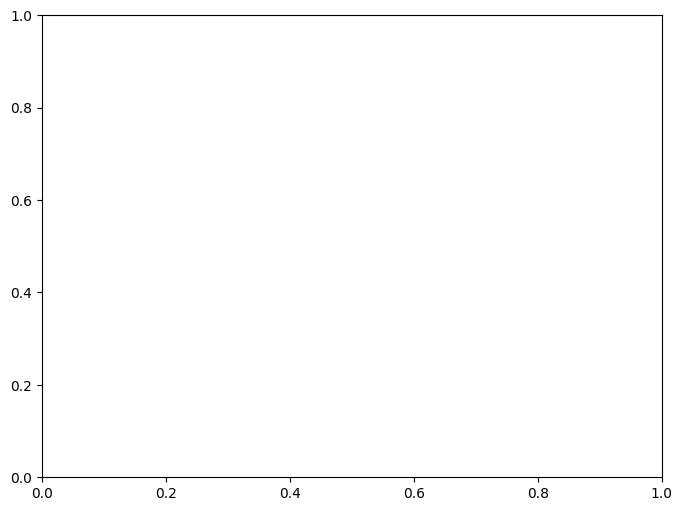

In [22]:

w = np.zeros(X_scaled.shape[1])
b = 0.0
alpha = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    w, b = gradient_descent_step(X_scaled, y, w, b, alpha)
    loss_history.append(compute_loss(X_scaled, y, w, b))
    
new_data_point = pd.DataFrame([{
    "weekday": 6,
    "is_weekend": 1,
    "active_users": 600,
    "restaurants": 25,
    "promotion": 1
}])

new_data_scaled = np.array((new_data_point - X_mean) / X_std)

predicted_orders = np.dot(new_data_scaled, w) + b


plt.figure(figsize=(8, 6))

plt.scatter(y, predicted_orders, color='#1f77b4', alpha=0.7, edgecolors='k', s=50, label='Data Days')

max_val = max(int(np.max(y)), int(np.max(predicted_orders)))

min_val = min(int(np.min(y)), int(np.min(predicted_orders)))
print(max_val)
print(min_val)

plt.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Model Performance Evaluation: Actual vs. Predicted Orders', fontsize=12, fontweight='bold')
plt.xlabel('Actual Order Quantities ($y$)', fontsize=11)
plt.ylabel('Model Predicted Quantities ($\hat{y}$)', fontsize=11)
plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.show()

--- Prediction Results ---
New Sample Data Input:
 weekday  is_weekend  active_users  restaurants  promotion
       3           1           500           25          1
Predicted Total Orders: 138.74



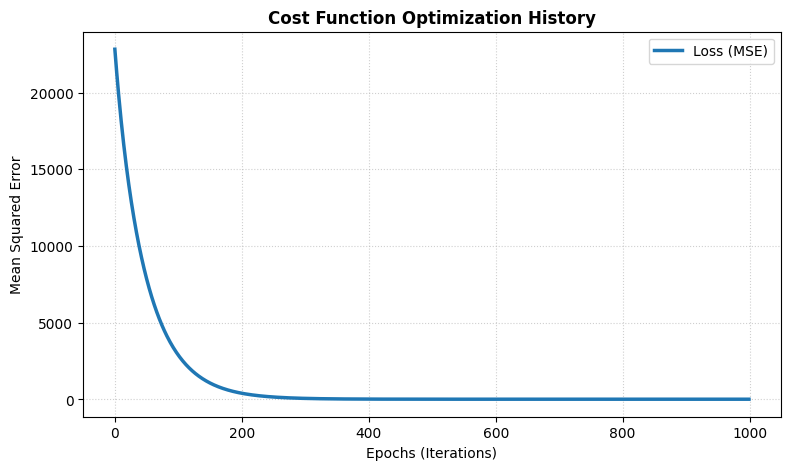

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare original data (dropping target leakage columns)
X_raw = df.drop(columns=["date", "orders", "completed_orders", "canceled_orders"])
y = df["orders"].values

# Compute scaling parameters from training data
X_mean = X_raw.mean()
X_std = X_raw.std()
X_scaled = np.array((X_raw - X_mean) / X_std)

# 2. Optimized functions
def compute_loss(X, y, w, b):
    return np.mean((np.dot(X, w) + b - y) ** 2)

def gradient_descent_step(X, y, w_now, b_now, alpha):
    num_samples = len(y)
    error = (np.dot(X, w_now) + b_now) - y
    w_gradient = (1 / num_samples) * np.dot(X.T, error)
    b_gradient = (1 / num_samples) * np.sum(error)
    return w_now - (alpha * w_gradient), b_now - (alpha * b_gradient)

# 3. Model Training Loop
w = np.zeros(X_scaled.shape[1])
b = 0.0
alpha = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    w, b = gradient_descent_step(X_scaled, y, w, b, alpha)
    loss_history.append(compute_loss(X_scaled, y, w, b))

# 4. Generate Predictions on New Data
# Imagine tomorrow is Saturday (6), weekend (1), 600 users, 25 restaurants, active promo (1)
new_data_point = pd.DataFrame([{
    "weekday": 3,
    "is_weekend": 1,
    "active_users": 500,
    "restaurants": 25,
    "promotion": 1
}])

# CRITICAL: Scale the new data using original mean and standard deviation
new_data_scaled = np.array((new_data_point - X_mean) / X_std)

# Compute final prediction using optimized weights
predicted_orders = np.dot(new_data_scaled, w) + b

print(f"--- Prediction Results ---")
print(f"New Sample Data Input:\n{new_data_point.to_string(index=False)}")
print(f"Predicted Total Orders: {predicted_orders[0]:.2f}\n")

# 5. Plot the Training History
plt.figure(figsize=(9, 5))
plt.plot(range(epochs), loss_history, color='#1f77b4', linewidth=2.5, label='Loss (MSE)')
plt.title('Cost Function Optimization History', fontsize=12, fontweight='bold')
plt.xlabel('Epochs (Iterations)', fontsize=10)
plt.ylabel('Mean Squared Error', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
